# 03. Gradient descent

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Estimated duration:** approximately 20 minutes.

Iterative optimization, learning rates, and descent in regression parameter space.

Run the cells from top to bottom. This notebook is one independent section of the workshop.

In [1]:
# --- Setup --- 

# Restart the kernel before running this cell if Matplotlib was already loaded.
import ipympl
# Enable interactive rotation and zooming for Matplotlib figures in VS Code.
get_ipython().run_line_magic("matplotlib", "ipympl")

# Import the numerical and plotting libraries used throughout the workshop.
import numpy as np
import matplotlib.pyplot as plt

# Choose plotting defaults that keep axes and mathematical curves readable.
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})

## 3. Gradient descent

Suggested time: 20 minutes.

The least-squares solution is useful, but it does not scale equally well to every model or dataset. We now replace the direct solve with iterative gradient-based optimization.

### 3.1 Why gradient descent?

Gradient descent is an iterative optimization algorithm. Instead of solving the normal equations in one large linear-algebra operation, it starts from an initial parameter vector and repeatedly moves in the direction that decreases the loss. This is the basic optimization mechanism used to train neural networks.

For $N$ observations and $d$ features, the normal-equation approach requires forming $\tilde{X}^T\tilde{X}$, which costs approximately $O(Nd^2)$ operations, and solving a $(d+1)\times(d+1)$ system, which costs approximately $O(d^3)$. A QR- or SVD-based solver is numerically safer, but it still becomes expensive when the number of features is large.

A full-batch gradient evaluation computes $\tilde{X}^T(\tilde{X}\theta-y)$ and costs approximately $O(Nd)$ per iteration. After $T$ iterations, the total cost is $O(TNd)$, and mini-batch methods can reduce the cost and memory used by each individual update. Gradient descent is therefore especially useful when the dataset is too large to fit comfortably in memory, when features arrive in batches, or when the model is nonlinear and no closed-form solution exists.

The trade-off is that gradient descent may require many iterations and depends on the learning rate and conditioning of the problem. It does not automatically make every small problem faster; its advantage is scalability and its direct connection to neural-network training. In remote sensing, this matters because a dataset can contain millions of pixels or patches, many spectral and spatial features, and models with millions of trainable parameters.



### 3.2 The gradient and update rule

For the linear regression loss

$$
\mathcal{L}(\theta)=\frac{1}{2N}\|\tilde{X}\theta-y\|_2^2,
$$

the gradient is

$$
\nabla_\theta\mathcal{L}(\theta)=\frac{1}{N}\tilde{X}^T(\tilde{X}\theta-y).
$$

The negative gradient points in the direction of steepest local decrease of the loss. With learning rate $\alpha>0$, gradient descent updates the parameters according to

$$
\theta_{k+1}=\theta_k-\alpha\nabla_\theta\mathcal{L}(\theta_k).
$$

The subscript $k$ denotes the iteration. Each update uses the current residuals to decide how the weights and bias should change. In a neural network, the same idea is applied to all trainable parameters, with the gradient obtained through backpropagation.



### 3.3 Learning rate and convergence

The learning rate controls the step size. If it is too small, the iterates move toward the minimum slowly. If it is too large, they can oscillate around the minimum or diverge. For a simple one-dimensional function, we can see the entire process directly.

Consider the more strongly curved quadratic $f(z)=(z-2)^2$. Its derivative is $f'(z)=2(z-2)$, so the unique minimum is at $z^\star=2$. Gradient descent becomes

$$
z_{k+1}=z_k-2\alpha(z_k-2).
$$

The next cell plots the function, the successive iterates, and the loss value at every step. The arrows show the direction selected by the negative gradient.

#### Visualization guide: gradient descent on a quadratic

This plot shows gradient descent moving along a one-dimensional objective toward its known minimum. The curve is the loss, and the successive markers show the parameter value after each update.

Look at the direction of each step and how the distance between successive points changes near the minimum. You can experiment with the initial value `z`, `learning_rate`, and `n_steps`.

**Open question:** What qualitative change occurs when the learning rate is too small or too large?

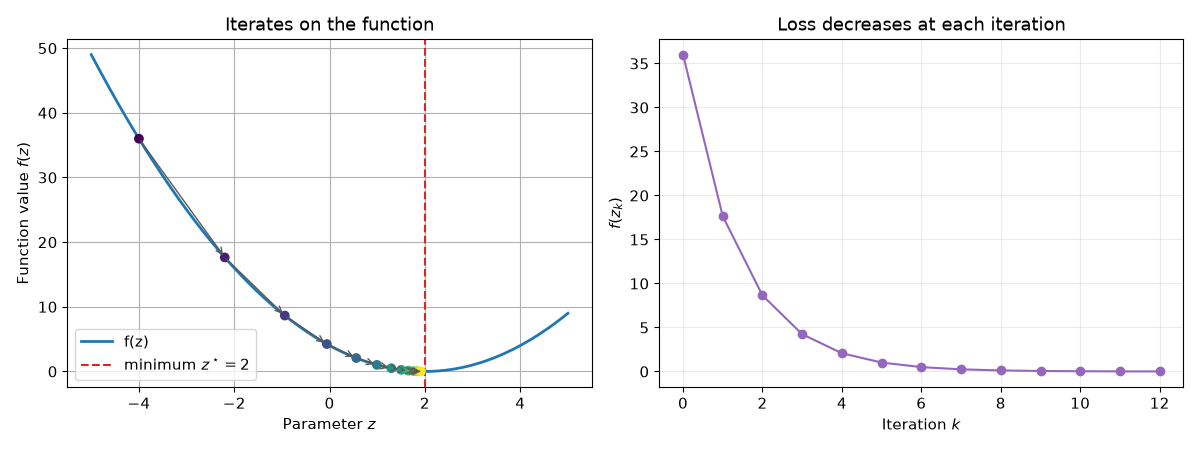

In [2]:
# The function and derivative have a known minimum at z_star = 2.
def f(z):
    return (z - 2.0) ** 2

def grad_f(z):
    return 2.0 * (z - 2.0)

z = -4.0
learning_rate = 0.15
n_steps = 12
z_history = [z]
f_history = [f(z)]

for _ in range(n_steps):
    # This is the gradient-descent update z_new = z - alpha * grad_f(z).
    z = z - learning_rate * grad_f(z)
    z_history.append(z)
    f_history.append(f(z))

z_grid = np.linspace(-5, 5, 400)
fig, (ax_function, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_function.plot(z_grid, f(z_grid), color="tab:blue", linewidth=2, label="f(z)")
ax_function.scatter(z_history, f_history, c=np.arange(len(z_history)), cmap="viridis", zorder=3)
for k in range(len(z_history) - 1):
    ax_function.annotate("", xy=(z_history[k + 1], f_history[k + 1]),
                        xytext=(z_history[k], f_history[k]),
                        arrowprops=dict(arrowstyle="->", color="0.35", lw=1))
ax_function.axvline(2.0, color="tab:red", linestyle="--", label="minimum $z^\star=2$")
ax_function.set_title("Iterates on the function")
ax_function.set_xlabel("Parameter $z$")
ax_function.set_ylabel("Function value $f(z)$")
ax_function.legend()

ax_loss.plot(range(len(f_history)), f_history, marker="o", color="tab:purple")
ax_loss.set_title("Loss decreases at each iteration")
ax_loss.set_xlabel("Iteration $k$")
ax_loss.set_ylabel("$f(z_k)$")
ax_loss.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### 3.4 Gradient descent on the regression problem

The same iterative rule can be applied to the two parameters of a one-feature regression model, $\theta=[b,w]^T$. The left panel below shows the loss contours in parameter space. The gradient-descent path moves toward the minimum, marked by the analytical least-squares solution. The right panel shows the loss decreasing with iterations. A second figure displays the same surface in 3D, with the trajectory descending toward the minimum.

#### Visualization guide: gradient descent in regression parameter space

Here the optimization variables are the bias and weight of a one-feature regression model. The contour plot and 3D surface show the loss as a function of these parameters, while the path shows the successive gradient-descent updates.

Look for the path descending toward the analytical least-squares solution and compare the contour spacing with the step sizes. You can change the initial parameters, `learning_rate`, the number of iterations, the sample noise, and the feature scale.

**Open question:** How would rescaling the input feature change the shape of the contours and the speed or stability of gradient descent?

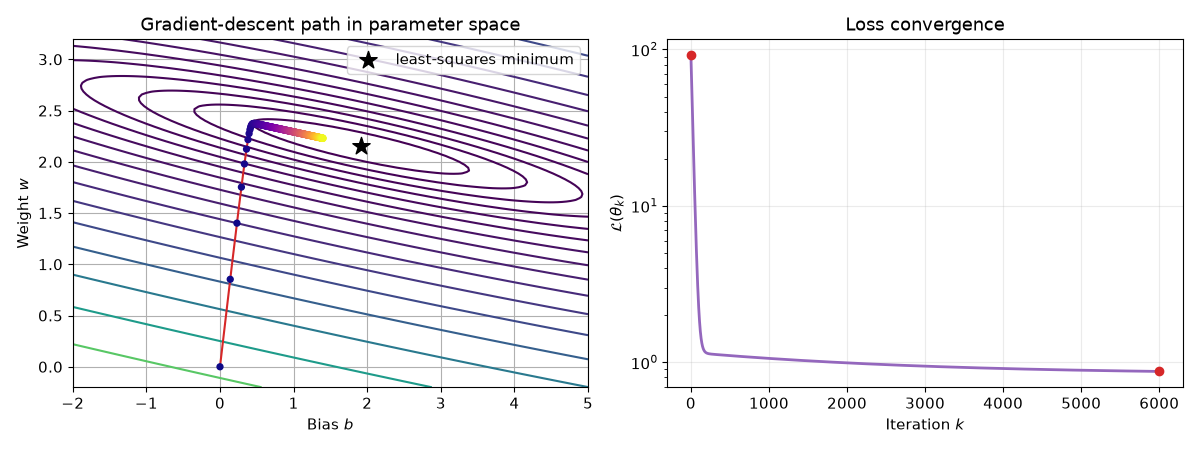

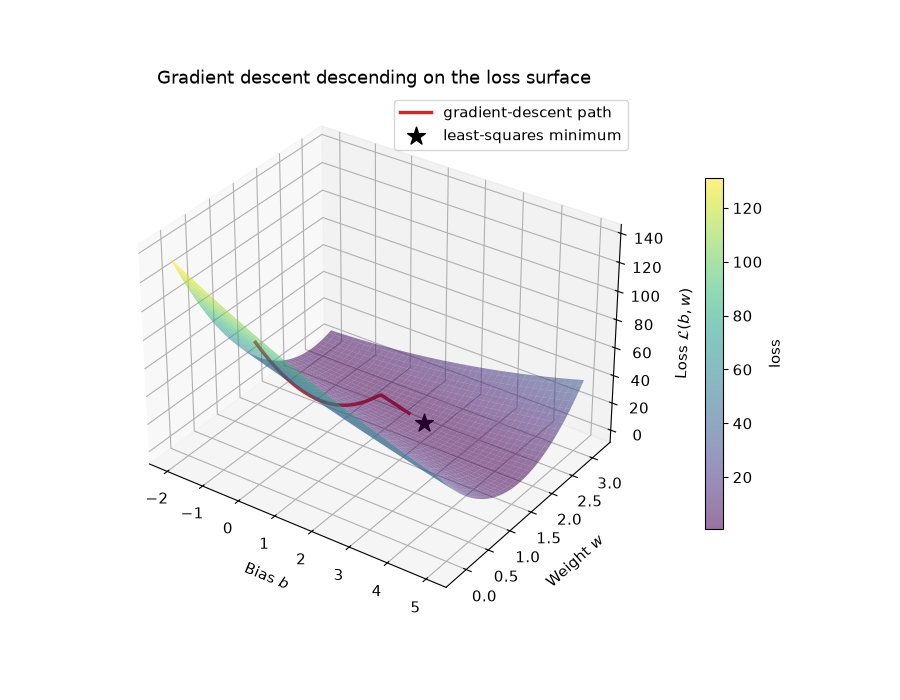

Least-squares solution: b = 1.910, w = 2.150
Gradient-descent solution: b = 1.400, w = 2.230


In [3]:
rng = np.random.default_rng(11)
n_samples = 40
x_reg = rng.uniform(0, 10, n_samples)
y_reg = 1.5 + 2.2 * x_reg + rng.normal(0, 1.5, n_samples)

# The augmented design matrix represents y_hat = X @ theta, with theta = [b, w]^T.
X_reg = np.c_[np.ones(n_samples), x_reg]

# This is the analytical reference solution from the least-squares problem.
theta_star, *_ = np.linalg.lstsq(X_reg, y_reg, rcond=None)

# Start from an initial parameter vector and repeatedly follow the negative gradient.
theta = np.array([.0, 0.0])
learning_rate = 0.0007
n_steps = 6000
theta_history = [theta.copy()]
loss_history = [0.5 * np.mean((X_reg @ theta - y_reg) ** 2)]

for _ in range(n_steps):
    # The residual is X @ theta - y; multiplying by X.T gives the parameter gradient.
    gradient = X_reg.T @ (X_reg @ theta - y_reg) / n_samples
    theta = theta - learning_rate * gradient
    theta_history.append(theta.copy())
    loss_history.append(0.5 * np.mean((X_reg @ theta - y_reg) ** 2))

theta_history = np.array(theta_history)
loss_star = 0.5 * np.mean((X_reg @ theta_star - y_reg) ** 2)

# Evaluate the loss on a grid to visualize the two-dimensional parameter surface.
b_grid = np.linspace(-2, 5, 120)
w_grid = np.linspace(-0.2, 3.2, 120)
B, W = np.meshgrid(b_grid, w_grid)
predictions = B[..., None] + W[..., None] * x_reg
loss_surface = 0.5 * np.mean((predictions - y_reg) ** 2, axis=2)
levels = np.geomspace(max(loss_surface.min(), 1e-3), loss_surface.max(), 18)

fig, (ax_path, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_path.contour(B, W, loss_surface, levels=levels, cmap="viridis")
ax_path.plot(theta_history[:, 0], theta_history[:, 1], color="tab:red", linewidth=1.5)
ax_path.scatter(theta_history[::20, 0], theta_history[::20, 1], c=np.arange(0, len(theta_history), 20),
                cmap="plasma", s=18, zorder=3)
ax_path.scatter(theta_star[0], theta_star[1], color="black", marker="*", s=170,
                label="least-squares minimum", zorder=4)
ax_path.set_title("Gradient-descent path in parameter space")
ax_path.set_xlabel("Bias $b$")
ax_path.set_ylabel("Weight $w$")
ax_path.legend()

ax_loss.semilogy(loss_history, color="tab:purple", linewidth=2)
ax_loss.scatter([0, n_steps], [loss_history[0], loss_history[-1]], color="tab:red", zorder=3)
ax_loss.set_title("Loss convergence")
ax_loss.set_xlabel("Iteration $k$")
ax_loss.set_ylabel(r"$\mathcal{L}(\theta_k)$")
ax_loss.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Display the same loss surface in three dimensions, including the descent path.
fig_3d = plt.figure(figsize=(9, 7))
ax_3d = fig_3d.add_subplot(111, projection="3d")
surface = ax_3d.plot_surface(B, W, loss_surface, cmap="viridis", alpha=0.55,
                             edgecolor="none", antialiased=True)
ax_3d.plot(theta_history[:, 0], theta_history[:, 1], loss_history,
           color="tab:red", linewidth=2.5, label="gradient-descent path")
ax_3d.scatter(theta_star[0], theta_star[1], loss_star, color="black", marker="*", s=180,
              label="least-squares minimum")
ax_3d.set_title("Gradient descent descending on the loss surface")
ax_3d.set_xlabel("Bias $b$", labelpad=8)
ax_3d.set_ylabel("Weight $w$", labelpad=8)
ax_3d.set_zlabel("Loss $\mathcal{L}(b,w)$", labelpad=8)
ax_3d.set_box_aspect((1.2, 1.0, 0.85))
ax_3d.view_init(elev=32, azim=-55)
fig_3d.colorbar(surface, ax=ax_3d, shrink=0.65, pad=0.1, label="loss")
ax_3d.legend(loc="upper right")
plt.show()

print(f"Least-squares solution: b = {theta_star[0]:.3f}, w = {theta_star[1]:.3f}")
print(f"Gradient-descent solution: b = {theta[0]:.3f}, w = {theta[1]:.3f}")